# Artifical Neural Network

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# Features 
X = np.array([
    [22, 50000], [25, 60000], [47, 120000], [52, 130000], [46, 115000],
    [56, 150000], [48, 110000], [55, 140000], [22, 50000], [23, 55000],
    [54, 135000], [48, 110000], [27, 65000], [30, 70000], [35, 75000],
    [40, 80000], [29, 62000], [33, 72000], [50, 125000], [31, 68000],
    [45, 112000], [53, 138000], [36, 76000], [38, 85000], [28, 58000],
    [26, 61000], [51, 129000], [34, 74000], [44, 108000], [32, 69000]
])

# Labels: 0 = Not Purchased, 1 = Purchased
Y = np.array([
    [0], [0], [1], [1], [1],
    [1], [1], [1], [0], [0],
    [1], [1], [0], [0], [1],
    [1], [0], [1], [1], [0],
    [1], [1], [1], [1], [0],
    [0], [1], [1], [1], [0]
])


In [3]:
# Normalization on Data
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_normalized = (X - X_min) / (X_max - X_min)

print("Normalized data (Age and Salary): \n", X_normalized)

Normalized data (Age and Salary): 
 [[0.         0.        ]
 [0.08823529 0.1       ]
 [0.73529412 0.7       ]
 [0.88235294 0.8       ]
 [0.70588235 0.65      ]
 [1.         1.        ]
 [0.76470588 0.6       ]
 [0.97058824 0.9       ]
 [0.         0.        ]
 [0.02941176 0.05      ]
 [0.94117647 0.85      ]
 [0.76470588 0.6       ]
 [0.14705882 0.15      ]
 [0.23529412 0.2       ]
 [0.38235294 0.25      ]
 [0.52941176 0.3       ]
 [0.20588235 0.12      ]
 [0.32352941 0.22      ]
 [0.82352941 0.75      ]
 [0.26470588 0.18      ]
 [0.67647059 0.62      ]
 [0.91176471 0.88      ]
 [0.41176471 0.26      ]
 [0.47058824 0.35      ]
 [0.17647059 0.08      ]
 [0.11764706 0.11      ]
 [0.85294118 0.79      ]
 [0.35294118 0.24      ]
 [0.64705882 0.58      ]
 [0.29411765 0.19      ]]


In [5]:
# Activation functions
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [6]:
input_layer_neurons = X_normalized.shape[1]
input_layer_neurons

2

In [27]:
hidden_layer_neurons = 5 # 2 neurons in hidden layer
output_neuron = 1 # binary classification

In [28]:
# initialize weights and biases
np.random.seed(42)
W1 = np.random.randn(input_layer_neurons, hidden_layer_neurons)
b1 = np.zeros((1, hidden_layer_neurons))
W2 = np.random.randn(hidden_layer_neurons, output_neuron)
b2 = np.zeros((1, output_neuron))

learning_rate = 0.1
epochs = 250

In [9]:
W1

array([[ 0.49671415, -0.1382643 ,  0.64768854],
       [ 1.52302986, -0.23415337, -0.23413696]])

In [23]:
W1.shape

(2, 3)

In [10]:
b1

array([[0., 0., 0.]])

In [11]:
W2

array([[ 1.57921282],
       [ 0.76743473],
       [-0.46947439]])

In [12]:
b2

array([[0.]])

In [29]:
# Training Neural Network
losses = []
accuracies = []
for epoch in range(epochs):
    # Forward propapagation
    Z1 = np.dot(X_normalized, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # compute loss
    loss = -np.mean(Y * np.log(A2) + (1-Y) * np.log(1-A2))
    losses.append(loss)

    # Backward propagation
    dA2 = A2 - Y
    dZ2 = dA2
    dW2 = np.dot(A1.T, dZ2)

    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X_normalized.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # update weights and biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # calculate accuracy 
    predictions = A2 > 0.5
    accuracy = np.mean(predictions == Y)
    accuracies.append(accuracy)
    print(f'Epoch {epoch}, Loss: {loss}, Accuracy: {accuracy*100:.2f}%')

Epoch 0, Loss: 1.568750777592231, Accuracy: 36.67%
Epoch 1, Loss: 0.8483752871999174, Accuracy: 63.33%
Epoch 2, Loss: 0.6526876767017764, Accuracy: 63.33%
Epoch 3, Loss: 0.5555757616084352, Accuracy: 63.33%
Epoch 4, Loss: 0.4374988452213421, Accuracy: 63.33%
Epoch 5, Loss: 0.3810550117379561, Accuracy: 73.33%
Epoch 6, Loss: 0.3655080056882238, Accuracy: 86.67%
Epoch 7, Loss: 0.3860924621235251, Accuracy: 73.33%
Epoch 8, Loss: 0.40211238671227256, Accuracy: 80.00%
Epoch 9, Loss: 0.3426662325515709, Accuracy: 76.67%
Epoch 10, Loss: 0.3554869431046869, Accuracy: 80.00%
Epoch 11, Loss: 0.3210017268339101, Accuracy: 80.00%
Epoch 12, Loss: 0.3224043355076012, Accuracy: 80.00%
Epoch 13, Loss: 0.2760264861572402, Accuracy: 86.67%
Epoch 14, Loss: 0.26275742315590134, Accuracy: 86.67%
Epoch 15, Loss: 0.21929082245138773, Accuracy: 90.00%
Epoch 16, Loss: 0.21666771401319795, Accuracy: 86.67%
Epoch 17, Loss: 0.19763156525535577, Accuracy: 90.00%
Epoch 18, Loss: 0.20109423676679053, Accuracy: 90.00

/tmp/ipykernel_290579/2453081796.py:12: RuntimeWarning: divide by zero encountered in log
  loss = -np.mean(Y * np.log(A2) + (1-Y) * np.log(1-A2))
/tmp/ipykernel_290579/2453081796.py:12: RuntimeWarning: invalid value encountered in multiply
  loss = -np.mean(Y * np.log(A2) + (1-Y) * np.log(1-A2))


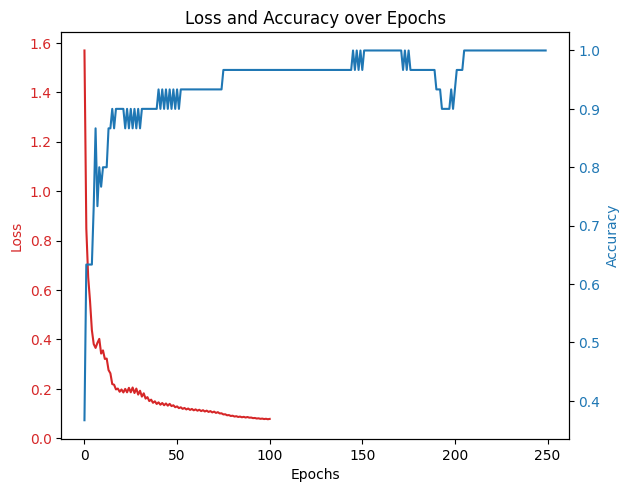

In [30]:
# plotting loss nd accuracy over epochs
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(range(epochs), losses, color='tab:red', label='loss')
ax1.tick_params(axis='y',labelcolor='tab:red')

ax2 = ax1.twinx() # 2nd axes that shares same x-axis
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(range(epochs), accuracies, color='tab:blue', label='accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()
plt.title("Loss and Accuracy over Epochs")
plt.show()

In [31]:
# prediction on normalized input data
def predict(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    return A2 > 0.5

# predictions on training data
predictions = predict(X_normalized)
accuracy = np.mean(predictions == Y)
print(f"Training Accuracy: {accuracy*100:.2f}%")

Training Accuracy: 100.00%


In [32]:
# predictions on unseen data
new_data = np.array([[28, 65000], [50, 130000]]) 
new_data_normalized = (new_data - X_min) / (X_max - X_min)
new_predictions = predict(new_data_normalized)
print("predictions on new data:\n", new_predictions)

predictions on new data:
 [[False]
 [ True]]


In [33]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true = Y.flatten()
y_pred = predictions.astype(int).flatten()

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix: ")
print(cm)

Confusion Matrix: 
[[11  0]
 [ 0 19]]


In [34]:
print("\nClassification Report: ")
print(classification_report(y_true, y_pred))


Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



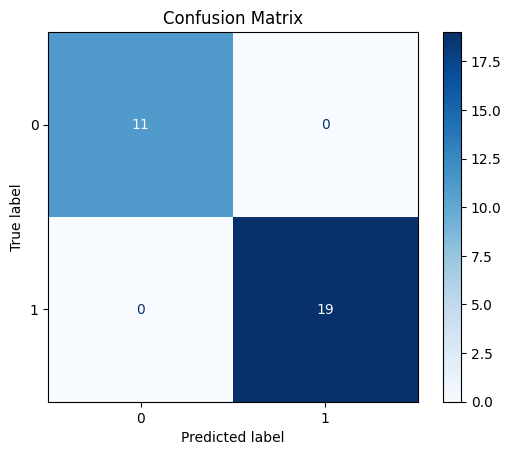

In [35]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()